# <center><strong><font color="green">Prueba - Análisis estadístico con Python</font></strong></center>

La OMS estima que cada año se producen 12 millones de muertes en todo el mundo debido
a enfermedades cardíacas, producidas en su gran mayoría por enfermedades
cardiovasculares. El pronóstico temprano de las enfermedades cardiovasculares puede
ayudar en la toma de decisiones sobre cambios en el estilo de vida en pacientes de alto
riesgo y reducir las complicaciones.
A partir de estos datos, buscaremos realizar algunas descripciones predictivos.
1. Carga los datos y explóralos. Elimina los datos nulos o incorrectos.

In [1]:
# Primero importamos las librerías que vamos a utilizar.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Creamos el dataframe usando 'pd.read_csv()'.
df= pd.read_csv('cardio.csv',delimiter=',')

# Mostramos el dataframe creado.
df

,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,M,39,4.0,No,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,F,46,2.0,No,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,M,48,1.0,Yes,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,F,61,3.0,Yes,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,F,46,3.0,Yes,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,M,50,1.0,Yes,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,M,51,3.0,Yes,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,F,48,2.0,Yes,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,F,44,1.0,Yes,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


In [2]:
# Vamos a ver un resumen estadístico.
df.describe(include="all")

,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238,4238.000000,4133.000000,4238,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
unique,2,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,F,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2419,NaN,NaN,2144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,49.584946,1.978950,NaN,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,NaN,8.572160,1.019791,NaN,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,NaN,32.000000,1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,NaN,42.000000,1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,NaN,49.000000,2.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,NaN,56.000000,3.000000,NaN,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000


In [3]:
# Revisamos duplicados.
df.duplicated().sum()

np.int64(0)

In [4]:
# Mostramos el tipo de dato y nulos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sex              4238 non-null   object 
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   object 
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(5), object(2)
memory usage: 529.9+ KB


In [5]:
# Podemos ver que no hay duplicados, pero si nulos asi que los vamos a eliminarlos.
df = df.dropna()

# Mostramos el dataframe resultante.
df

,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,M,39,4.0,No,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,F,46,2.0,No,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,M,48,1.0,Yes,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,F,61,3.0,Yes,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,F,46,3.0,Yes,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4231,M,58,3.0,No,0.0,0.0,0,1,0,187.0,141.0,81.0,24.96,80.0,81.0,0
4232,M,68,1.0,No,0.0,0.0,0,1,0,176.0,168.0,97.0,23.14,60.0,79.0,1
4233,M,50,1.0,Yes,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,M,51,3.0,Yes,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0


2. Escoge tres variables cuantitativas y realiza un análisis descriptivo de ellas,
utilizando indicadores y gráficos. ¿Cuaĺ presenta mayor dispersión?

In [6]:
# Vamos a elegir "Age", "BMI" y "sysBP". 
# Seleccionamos las columnas necesarias para poder comenzar a trabajar (Creamos un nuevo dataframe).
df1=df[["age", "BMI", "sysBP"]]

# Mostramos el dataframe.
df1

,age,BMI,sysBP
0,39,26.97,106.0
1,46,28.73,121.0
2,48,25.34,127.5
3,61,28.58,150.0
4,46,23.10,130.0
...,...,...,...
4231,58,24.96,141.0
4232,68,23.14,168.0
4233,50,25.97,179.0
4234,51,19.71,126.5


In [7]:
# Vamos a realizar el analisis descriptivo de las varibles.
# Creamos una lista para poder comenzar.
variables = ["age", "BMI", "sysBP"]

In [8]:
# Cremos algunas funciones para poder calcular algunas de las medidas de dispersión.
def rango(x):
    return x.max() - x.min()

def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

def desviacion_media(x):
    return np.mean(np.abs(x - x.mean()))

In [9]:
# Creamos un diccionario para poder guardar los resultados.
resultados = {}

# Utilizamos un ciclo for para recorer la lista que creamos anteriormente.
for var in variables:
    resumen = {
        "media": df[var].mean(),
        "mediana": df[var].median(),
        "rango": rango(df[var]),
        "rango_intercuartil": iqr(df[var]),
        "desviacion_media": desviacion_media(df[var]),
        "varianza": df[var].var(),
        "desviacion_std": df[var].std(),
        "cantidad": df[var].count()
    }
    
    resultados[var] = resumen # Guarmados los resultados en el el diccionario.

    # Mostramos los resultados.
    print(f"\n📊 Análisis estadístico de la variable: {var}")
    for k, v in resumen.items():
        print(f"{k}: {v:.1f}")


📊 Análisis estadístico de la variable: age
media: 49.6
mediana: 49.0
rango: 38.0
rango_intercuartil: 14.0
desviacion_media: 7.3
varianza: 73.3
desviacion_std: 8.6
cantidad: 3656.0

📊 Análisis estadístico de la variable: BMI
media: 25.8
mediana: 25.4
rango: 41.3
rango_intercuartil: 5.0
desviacion_media: 3.1
varianza: 16.5
desviacion_std: 4.1
cantidad: 3656.0

📊 Análisis estadístico de la variable: sysBP
media: 132.4
mediana: 128.0
rango: 211.5
rango_intercuartil: 27.0
desviacion_media: 16.9
varianza: 488.1
desviacion_std: 22.1
cantidad: 3656.0


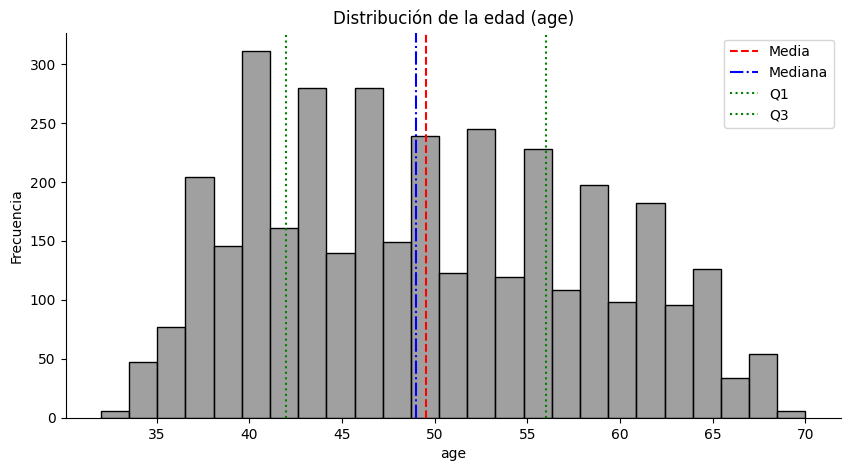

In [10]:
# Graficamos.
fig, axes = plt.subplots(nrows=1, figsize=(10,5))

sns.histplot(df["age"], bins=25, color="gray")

axes.axvline(df["age"].mean(), color="red", linestyle="--", label="Media")
axes.axvline(df["age"].median(), color="blue", linestyle="-.", label="Mediana")
axes.axvline(df["age"].quantile(0.25), color="green", linestyle=":", label="Q1")
axes.axvline(df["age"].quantile(0.75), color="green", linestyle=":", label="Q3")

axes.set_title("Distribución de la edad (age)")
axes.set_xlabel("age")
axes.set_ylabel("Frecuencia")

axes.legend()
sns.despine()
plt.show()

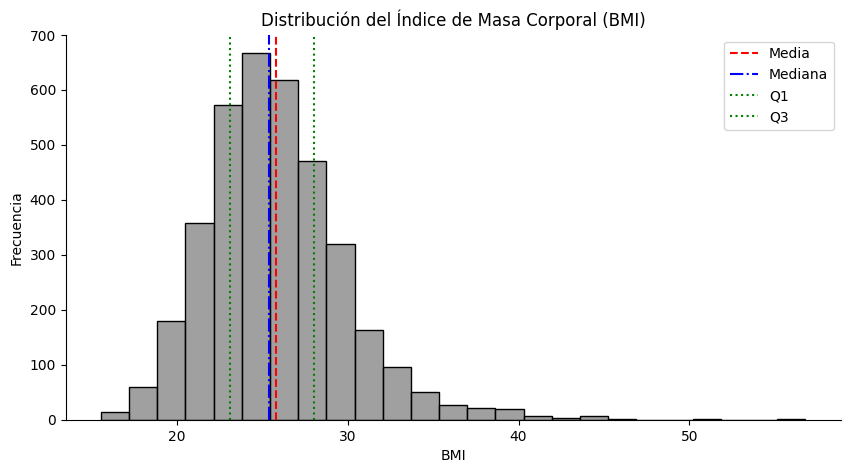

In [11]:
fig, axes = plt.subplots(nrows=1, figsize=(10,5))

sns.histplot(df["BMI"], bins=25, color="gray")

axes.axvline(df["BMI"].mean(), color="red", linestyle="--", label="Media")
axes.axvline(df["BMI"].median(), color="blue", linestyle="-.", label="Mediana")
axes.axvline(df["BMI"].quantile(0.25), color="green", linestyle=":", label="Q1")
axes.axvline(df["BMI"].quantile(0.75), color="green", linestyle=":", label="Q3")

axes.set_title("Distribución del Índice de Masa Corporal (BMI)")
axes.set_xlabel("BMI")
axes.set_ylabel("Frecuencia")

axes.legend()
sns.despine()
plt.show()

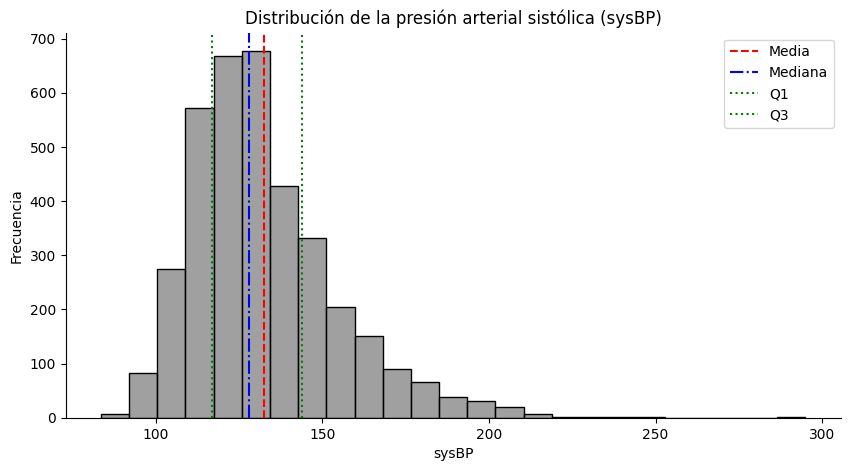

In [12]:
fig, axes = plt.subplots(nrows=1, figsize=(10,5))

sns.histplot(df["sysBP"], bins=25, color="gray")

axes.axvline(df["sysBP"].mean(), color="red", linestyle="--", label="Media")
axes.axvline(df["sysBP"].median(), color="blue", linestyle="-.", label="Mediana")
axes.axvline(df["sysBP"].quantile(0.25), color="green", linestyle=":", label="Q1")
axes.axvline(df["sysBP"].quantile(0.75), color="green", linestyle=":", label="Q3")

axes.set_title("Distribución de la presión arterial sistólica (sysBP)")
axes.set_xlabel("sysBP")
axes.set_ylabel("Frecuencia")

axes.legend()
sns.despine()
plt.show()

#### Conclusión
Al comparar las medidas de dispersión de las tres variables analizadas, se concluye que la presión arterial sistólica (sysBP) presenta la mayor dispersión, seguida por la edad, mientras que el índice de masa corporal (BMI) muestra la menor variabilidad.

En consecuencia, la media resulta menos representativa para la variable sysBP (presión arterial sistólica), debido a la amplia variabilidad de sus valores, mientras que en el caso del BMI(Índice de Masa Corporal) la media constituye un indicador más adecuado del comportamiento general de los datos.

3. Elimina los datos atípicos del dataset. Para las siguientes preguntas, considera el
dataset "limpio".

In [13]:
# Para comenzar la limpieza vamos a separar las variables cuantitativas continuas.
variables_outliers = ["age", "BMI", "sysBP", "diaBP", "totChol", "glucose","heartRate"]

In [14]:
# Función para eliminar los outliers.
def eliminar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return df[(df[columna] >= limite_inferior) & (df[columna] <= limite_superior)]

In [15]:
# Hacemos una copia del dataframe original.
df_limpio = df.copy()

# Aplicamos la función con un ciclo for.
for var in variables_outliers:
    df_limpio = eliminar_outliers_iqr(df_limpio, var)

# Mostramos el df.
df_limpio

,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,M,39,4.0,No,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,F,46,2.0,No,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,M,48,1.0,Yes,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,F,61,3.0,Yes,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,F,46,3.0,Yes,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4231,M,58,3.0,No,0.0,0.0,0,1,0,187.0,141.0,81.0,24.96,80.0,81.0,0
4232,M,68,1.0,No,0.0,0.0,0,1,0,176.0,168.0,97.0,23.14,60.0,79.0,1
4233,M,50,1.0,Yes,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,M,51,3.0,Yes,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0


4. ¿Qué variables cuantitativas presentan mayor correlación? Explica.

In [16]:
#Trabajamos únicamente con variables cuantitativas continuas relevantes.
variables_cuant = ["age", "BMI", "sysBP", "diaBP","totChol", "glucose", "heartRate"]

In [17]:
corr=df_limpio[variables_cuant].corr()
corr

,age,BMI,sysBP,diaBP,totChol,glucose,heartRate
age,1.000000,0.126201,0.362217,0.179855,0.276207,0.083613,-0.034032
BMI,0.126201,1.000000,0.270967,0.332314,0.157162,0.060927,0.041906
sysBP,0.362217,0.270967,1.000000,0.757071,0.210567,0.075863,0.153141
diaBP,0.179855,0.332314,0.757071,1.000000,0.198326,0.023696,0.160492
totChol,0.276207,0.157162,0.210567,0.198326,1.000000,0.017090,0.088068
glucose,0.083613,0.060927,0.075863,0.023696,0.017090,1.000000,0.074529
heartRate,-0.034032,0.041906,0.153141,0.160492,0.088068,0.074529,1.000000


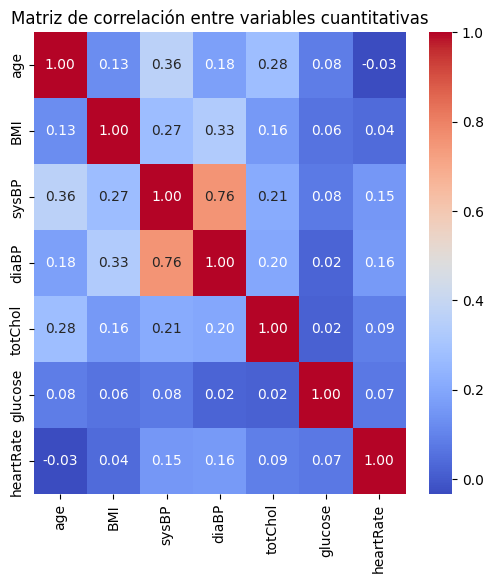

In [18]:
# Graficamos la matriz de correlación.
plt.figure(figsize=(6,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables cuantitativas")
plt.show()

#### Conclusión
En general, las correlaciones observadas entre las variables cuantitativas del conjunto de datos son bajas, lo que indica una débil relación lineal entre la mayoría de ellas.
La única asociación claramente significativa se observa entre la presión arterial sistólica (sysBP) y la presión arterial diastólica (diaBP), con una correlación alta (r ≈ 0.76), lo cual es esperable dado que ambas variables miden distintos aspectos de la presión arterial.
Por otro lado, la edad y el índice de masa corporal (BMI) presentan correlaciones positivas pero moderadas con algunas variables cardiovasculares, como la presión arterial y el colesterol total, aunque estas asociaciones no son lo suficientemente fuertes como para indicar una relación lineal marcada.

5. Si de este dataset se escoge un paciente al azar, ¿cuál es la probabilidad de que sea
hombre, si se sabe que pertenece al mayor cuartil de la variable correspondiente al
índice de masa corporal?

In [19]:
# Probabilidad de que el paciente sea hombre, dado que pertenece al cuartil superior del BMI.
# Primero calculamos el percentil 75 (Q3) del BMI.
q3_bmi = df_limpio["BMI"].quantile(0.75)
q3_bmi

np.float64(27.68)

In [20]:
# Subconjunto de personas con BMI alto.
bmi_alto = df_limpio[df_limpio["BMI"] >= q3_bmi]

In [21]:
# Cálculo de la probabilidad condicional.
# P(Hombre∣ BMI alto) = Cantidad de hombres con BMI alto/Cantidad total de personas con BMI alto 
prob_hombre = len(bmi_alto[bmi_alto["sex"] == "M"]) / len(bmi_alto)
prob_hombre

0.5366161616161617

#### Conclusión
El resultado obtenido indica que la probabilidad de que un paciente sea hombre, sabiendo que pertenece al mayor cuartil del BMI, es de 53,66 %.
Este valor sugiere que, dentro del grupo de pacientes con mayor índice de masa corporal, la proporción de hombres es ligeramente superior al 50 %, lo que indica una leve predominancia masculina en este segmento del conjunto de datos.

6. ¿Es razonable afirmar que, para una persona cualquiera (no necesariamente dentro
del dataset), su ritmo cardiaco promedio es 75? Explica y justifica.

Vamos a utilizar un test t de Student bilateral porque se contrasta una media poblacional con desviación desconocida y se desea evaluar si dicha media difiere del valor 75 en cualquier sentido.

In [22]:
# Hipótesis:
# H₀: μ = 75
# H₁: μ ≠ 75
# α = 0.05

# Extraemos la variable ritmo cardíaco del dataset limpio.
heart_rate = df_limpio["heartRate"]

# Estadísticos muestrales.
media_muestral = heart_rate.mean()
std_muestral = heart_rate.std()
n = heart_rate.count()

print("Media muestral:", round(media_muestral, 2))
print("Desviación estándar muestral:", round(std_muestral, 2))
print("Tamaño de la muestra:", n)

# Test t para una muestra.
t_stat, p_value = stats.ttest_1samp(heart_rate, popmean=75)

print("\nEstadístico t:", round(t_stat, 4))
print("p-valor:", round(p_value, 6))

Media muestral: 74.52
Desviación estándar muestral: 10.65
Tamaño de la muestra: 3160

Estadístico t: -2.5395
p-valor: 0.011148


In [23]:
alpha = 0.05
if p_value < alpha:
    print("Se rechaza la hipótesis nula: la media es distinta de 75.")
else:
    print("No se rechaza la hipótesis nula: la media podría ser 75.")

Se rechaza la hipótesis nula: la media es distinta de 75.


##### Respuesta:
Con un nivel de significancia del 5 %, existe evidencia estadística suficiente para afirmar que el ritmo cardíaco promedio poblacional no es igual a 75 latidos por minuto.
Por lo tanto, no es razonable sostener que, para una persona cualquiera, el ritmo cardíaco promedio sea exactamente 75, ya que la media observada difiere significativamente de dicho valor.

7. Ser hombre, ¿influye en el promedio de cigarrillos consumidos por día, dentro de los
pacientes fumadores? Explica.

Se desea analizar si ser hombre influye en el promedio de cigarrillos consumidos por día, considerando únicamente a los pacientes fumadores del dataset.
Para ello, vamos a comparar los promedios de consumo diario de cigarrillos entre hombres y mujeres fumadores, utilizando un test t para muestras independientes.

**Hipótesis:**
- H₀: El consumo promedio de cigarrillos por día es igual en hombres y mujeres fumadores.
- H₁: El consumo promedio de cigarrillos por día es diferente entre hombres y mujeres fumadores.
  
**Nivel de significancia: 𝛼=0.05**

In [24]:
# Filtramos a los fumadores.
fumadores = df_limpio[df_limpio["currentSmoker"] == "Yes"]

# Separamos el consumo de cigarrillos por sexo.
cigs_hombres = fumadores[fumadores["sex"] == "M"]["cigsPerDay"]
cigs_mujeres = fumadores[fumadores["sex"] == "F"]["cigsPerDay"]

# Estadísticos descriptivos.
print("Media hombres:", round(cigs_hombres.mean(), 2))
print("Media mujeres:", round(cigs_mujeres.mean(), 2))

Media hombres: 22.31
Media mujeres: 14.02


In [25]:
# Test de Fisher.
f_stat, p_fisher = stats.levene(cigs_hombres, cigs_mujeres)

print("Test de Fisher")
print("Estadístico F:", round(f_stat, 4))
print("p-valor:", round(p_fisher, 6))

Test de Fisher
Estadístico F: 0.9725
p-valor: 0.324219


In [26]:
alpha = 0.05

if p_fisher < alpha:
    print("Se rechaza H₀: las varianzas son distintas.")
    equal_var = False
else:
    print("No se rechaza H₀: no hay evidencia de varianzas distintas.")
    equal_var = True

No se rechaza H₀: no hay evidencia de varianzas distintas.


In [27]:
#Test t para muestras independientes.
t_stat, p_value = stats.ttest_ind(
    cigs_hombres,
    cigs_mujeres,
    equal_var=equal_var
)

print("Estadístico t:", round(t_stat, 4))
print("p-valor:", round(p_value, 8))

Estadístico t: 16.3402
p-valor: 0.0


##### Conclusión:
El test de Fisher no evidenció diferencias significativas en las varianzas del consumo diario de cigarrillos entre hombres y mujeres fumadores (p = 0.3242), por lo que se asumió igualdad de varianzas. Bajo este supuesto, el test t para muestras independientes permitió rechazar la hipótesis nula de igualdad de medias (p < 0.05), indicando que el consumo promedio de cigarrillos por día difiere significativamente según el sexo, siendo mayor en los hombres.

8. Construye un modelo de regresión lineal que permita relacionar 6 variables del
dataset con el índice de masa corporal. (Debes incluir al menos dos variables
cualitativas). Evalúa tu modelo y explica.

In [28]:
# Selección de varaibles.
# Variables Cuantitativas: age, sysBP, cigsPerDay, glucose.
# Variables Cualitativas: sex y currentSmoker.

In [29]:
# Selección de variables.
X = df_limpio[['age', 'sysBP', 'cigsPerDay', 'glucose', 'sex', 'currentSmoker']]
y = df_limpio['BMI']

In [30]:
# Codificación de variables cualitativas (get_dummies).
X_encoded = pd.get_dummies(
    X,
    columns=['sex', 'currentSmoker'],
    drop_first=True,
    dtype=float
)

In [31]:
# Tratamiento de valores faltantes.
X_encoded = X_encoded.fillna(X_encoded.mean())
y = y.fillna(y.mean())

In [32]:
# Agregar constante.
X_encoded = sm.add_constant(X_encoded)

In [33]:
# Ajuste del modelo.
model_multi = sm.OLS(y, X_encoded).fit()

In [34]:
# Mostramos resultados y métricas.
results = model_multi.summary()
predictions = model_multi.predict(X_encoded)

mse = ((y - predictions) ** 2).mean()
emse = mse / ((y - y.mean()) ** 2).mean()
r2 = model_multi.rsquared

print(results)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Error Mean Squared Explicado (EMSE): {emse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")

                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     71.98
Date:                Thu, 15 Jan 2026   Prob (F-statistic):           2.35e-84
Time:                        14:17:42   Log-Likelihood:                -8203.5
No. Observations:                3160   AIC:                         1.642e+04
Df Residuals:                    3153   BIC:                         1.646e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                18.3343      0.62

##### Conclusión: 
- R² = 0.12.El modelo explica aproximadamente el 12% de la variabilidad del índice de masa corporal (BMI). Esto indica una capacidad explicativa baja, lo cual es esperable dado que el BMI está influido por múltiples factores que no fueron incluidos en el modelo, como la actividad física, los hábitos alimentarios, factores genéticos y socioeconómicos, entre otros.
- EMSE = 0.88. El Error Medio Cuadrático Explicado indica que el 88% del error total no es explicado por el modelo, lo cual es coherente con el bajo valor de R². Esto refuerza la idea de que, si bien el modelo captura algunas relaciones estadísticamente significativas, su capacidad predictiva global es limitada.
- Intercepto (const = 18.33).El intercepto representa el valor estimado del BMI cuando todas las variables explicativas toman el valor cero y las variables categóricas se encuentran en sus categorías de referencia. Aunque esta situación no resulta realista desde el punto de vista práctico, el intercepto es necesario para el correcto ajuste del modelo y permite interpretar adecuadamente los coeficientes de las variables independientes.
- Significancia de variables. Variables como la presión sistólica (sysBP) y el sexo masculino (sex_M) presentan efectos estadísticamente significativos sobre el BMI.

9. Construye un modelo de regresión logística para predecir el riesgo de sufrir una
enfermedad coronaria en los próximos diez años, a partir de las variables descritas.
Verifica el balanceo de datos y evalúa tu modelo.

In [46]:
# Variables.
X = df_limpio.drop("TenYearCHD", axis=1)
y = df_limpio["TenYearCHD"]

In [47]:
# Codificamos las variables categóricas.
X = pd.get_dummies(X, drop_first=True)

Distribución de la variable objetivo:
TenYearCHD
0    0.868987
1    0.131013
Name: proportion, dtype: float64


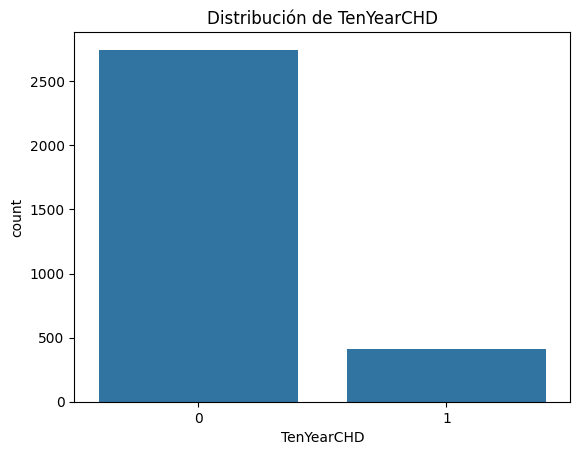

In [48]:
# Verificamos el desbalanceo.
print("Distribución de la variable objetivo:")
print(y.value_counts(normalize=True))

# Graficamos.
sns.countplot(x=y)
plt.title("Distribución de TenYearCHD")
plt.show()

In [49]:
# Dividimos el dataset en entrenamiento y prueba.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [39]:
# Escalamos.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
# Aplicamos SMOTE (solo en train).
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled, y_train
)

print("Distribución después de SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Distribución después de SMOTE:
TenYearCHD
0    1922
1    1922
Name: count, dtype: int64


In [41]:
# Entrenamos el modelo.
model = LogisticRegression(max_iter=1000)
model.fit(X_train_smote, y_train_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [42]:
# Predicciones.
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [43]:
# Evaluación.
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)

Matriz de confusión:
[[552 272]
 [ 44  80]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.93      0.67      0.78       824
           1       0.23      0.65      0.34       124

    accuracy                           0.67       948
   macro avg       0.58      0.66      0.56       948
weighted avg       0.83      0.67      0.72       948

ROC-AUC: 0.7220188694018164


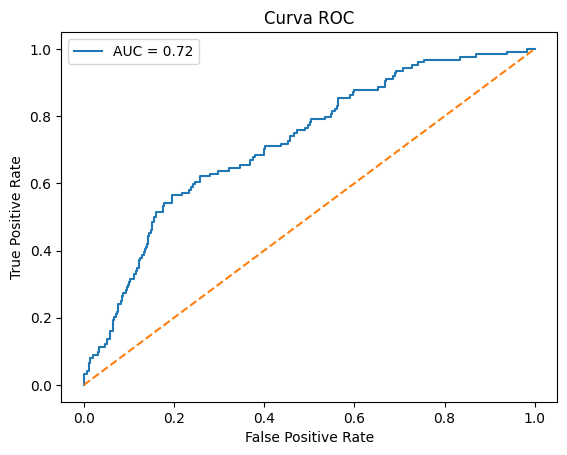

In [44]:
# Graficamos la curva ROC.
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

#### Conclusión:
El análisis de la variable objetivo evidenció un desbalance de clases, con una menor proporción de individuos con riesgo coronario, por lo que se aplicó la técnica de SMOTE sobre el conjunto de entrenamiento.
La evaluación del modelo se realizó mediante matriz de confusión, reporte de clasificación y curva ROC con su correspondiente AUC. El modelo entrenado con SMOTE logró mejorar la identificación de la clase minoritaria, alcanzando identificar correctamente el 65% para los casos positivos. El valor obtenido de ROC-AUC = 0.72 indica una capacidad de discriminación aceptable.
En conclusión, el uso de técnicas de balanceo junto con métricas adecuadas permitió obtener un modelo que cumple con los objetivos planteados y resulta apropiado para la predicción del riesgo coronario.

10. Separa los modelos de regresión anteriores en dos distintos, respectivamente,
considerando alguna variable categórica. Compara y concluye.

In [57]:
# Vamos a utilizar la variable 'sex'.

#Creamos los subconjuntos.
df_mujeres = df_limpio[df_limpio["sex"] == 'F']
df_hombres = df_limpio[df_limpio["sex"] == 'M']

# Mostramos los subconjuntos.
df_mujeres

,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
1,F,46,2.0,No,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
3,F,61,3.0,Yes,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,F,46,3.0,Yes,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
6,F,63,1.0,No,0.0,0.0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1
7,F,45,2.0,Yes,20.0,0.0,0,0,0,313.0,100.0,71.0,21.68,79.0,78.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4214,F,56,3.0,Yes,5.0,0.0,0,0,0,230.0,123.0,78.5,24.71,76.0,87.0,1
4216,F,59,3.0,Yes,20.0,0.0,0,0,0,251.0,125.0,80.0,22.18,70.0,70.0,0
4217,F,63,1.0,No,0.0,0.0,0,1,0,266.0,167.0,94.0,25.23,95.0,94.0,0
4218,F,52,1.0,No,0.0,0.0,0,0,0,265.0,137.5,84.5,26.91,72.0,86.0,0


In [58]:
df_hombres

,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,M,39,4.0,No,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
2,M,48,1.0,Yes,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
8,M,52,1.0,No,0.0,0.0,0,1,0,260.0,141.5,89.0,26.36,76.0,79.0,0
9,M,43,1.0,Yes,30.0,0.0,0,1,0,225.0,162.0,107.0,23.61,93.0,88.0,0
12,M,46,1.0,Yes,15.0,0.0,0,1,0,294.0,142.0,94.0,26.31,98.0,64.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4227,M,43,4.0,Yes,20.0,0.0,0,0,0,187.0,129.5,88.0,25.62,80.0,75.0,0
4231,M,58,3.0,No,0.0,0.0,0,1,0,187.0,141.0,81.0,24.96,80.0,81.0,0
4232,M,68,1.0,No,0.0,0.0,0,1,0,176.0,168.0,97.0,23.14,60.0,79.0,1
4233,M,50,1.0,Yes,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1


In [61]:
# Vamos a eliminar la columna 'sex' porque ya no la necesitamos.
df_mujeres = df_mujeres.drop("sex", axis=1)
df_hombres = df_hombres.drop("sex", axis=1)

In [59]:
# Variables para el subconjunto de mujeres.
X_mujeres = df_mujeres.drop("TenYearCHD", axis=1)
y_mujeres = df_mujeres["TenYearCHD"]

In [69]:
# Convertir variables categóricas a numéricas.
X_mujeres = pd.get_dummies(X_mujeres, drop_first=True)

Distribución TenYearCHD - Mujeres
TenYearCHD
0    1556
1     166
Name: count, dtype: int64
TenYearCHD
0    0.9036
1    0.0964
Name: proportion, dtype: float64


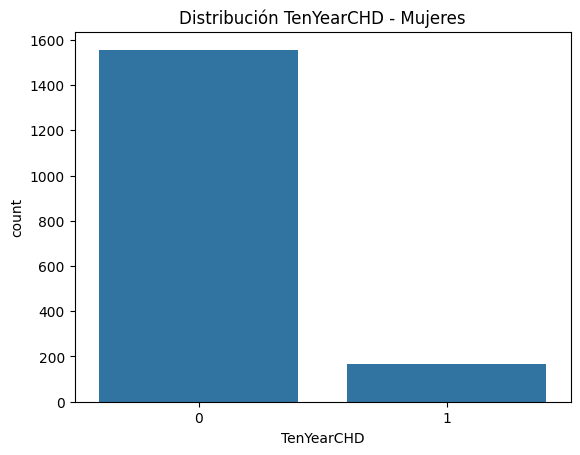

In [70]:
# Verificamos el desbalanceo.
print("Distribución TenYearCHD - Mujeres")
print(y_mujeres.value_counts())
print(y_mujeres.value_counts(normalize=True))

# Graficamos.
sns.countplot(x=y_mujeres)
plt.title("Distribución TenYearCHD - Mujeres")
plt.show()

In [71]:
# Está desbalanceado, entonces vamos a utilizar SMOTE.

# Dividimos el dataset en entrenamiento y prueba.
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mujeres,
    y_mujeres,
    test_size=0.3,
    random_state=42,
    stratify=y_mujeres
)

In [72]:
# Escalamos.
scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled = scaler_m.transform(X_test_m)

In [73]:
# Aplicamos SMOTE.
smote_m = SMOTE(random_state=42)
X_train_m_smote, y_train_m_smote = smote_m.fit_resample(
    X_train_m_scaled,
    y_train_m
)

print("Distribución después de SMOTE - Mujeres:")
print(pd.Series(y_train_m_smote).value_counts())

Distribución después de SMOTE - Mujeres:
TenYearCHD
0    1089
1    1089
Name: count, dtype: int64


In [74]:
# Entrenamos el modelo.
model_m = LogisticRegression(max_iter=1000)
model_m.fit(X_train_m_smote, y_train_m_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [75]:
# Predicciones.
y_pred_m = model_m.predict(X_test_m_scaled)
y_prob_m = model_m.predict_proba(X_test_m_scaled)[:, 1]

In [76]:
# Evaluación.
print("Matriz de confusión - Mujeres:")
print(confusion_matrix(y_test_m, y_pred_m))

print("\nReporte de clasificación - Mujeres:")
print(classification_report(y_test_m, y_pred_m))

auc_m = roc_auc_score(y_test_m, y_prob_m)
print("ROC-AUC - Mujeres:", auc_m)

Matriz de confusión - Mujeres:
[[316 151]
 [ 22  28]]

Reporte de clasificación - Mujeres:
              precision    recall  f1-score   support

           0       0.93      0.68      0.79       467
           1       0.16      0.56      0.24        50

    accuracy                           0.67       517
   macro avg       0.55      0.62      0.51       517
weighted avg       0.86      0.67      0.73       517

ROC-AUC - Mujeres: 0.7202569593147752


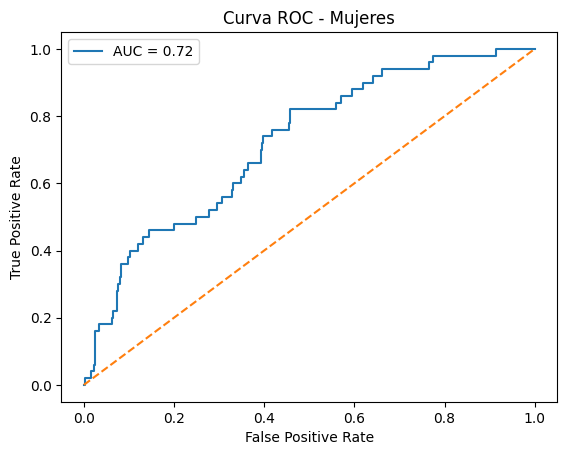

In [77]:
# Graficamos la curva ROC.
fpr_m, tpr_m, _ = roc_curve(y_test_m, y_prob_m)

plt.plot(fpr_m, tpr_m, label=f"AUC = {auc_m:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Mujeres")
plt.legend()
plt.show()

In [78]:
# Variables para el subconjunto de hombres.
X_hombres = df_hombres.drop("TenYearCHD", axis=1)
y_hombres = df_hombres["TenYearCHD"]

In [79]:
# Convertir variables categóricas a numéricas.
X_hombres = pd.get_dummies(X_hombres, drop_first=True)

Distribución TenYearCHD - Hombres
TenYearCHD
0    1190
1     248
Name: count, dtype: int64
TenYearCHD
0    0.827538
1    0.172462
Name: proportion, dtype: float64


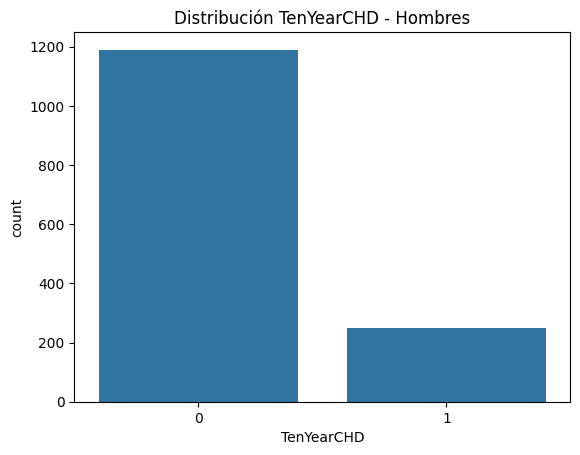

In [83]:
# Verificamos el desbalanceo.
print("Distribución TenYearCHD - Hombres")
print(y_hombres.value_counts())
print(y_hombres.value_counts(normalize=True))

# Graficamos.
sns.countplot(x=y_hombres)
plt.title("Distribución TenYearCHD - Hombres")
plt.show()

In [84]:
# Está desbalanceado, entonces vamos a utilizar SMOTE.

# Dividimos el dataset en entrenamiento y prueba.
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_hombres,
    y_hombres,
    test_size=0.3,
    random_state=42,
    stratify=y_hombres
)

In [86]:
# Escalamos.
scaler_h = StandardScaler()
X_train_h_scaled = scaler_h.fit_transform(X_train_h)
X_test_h_scaled = scaler_h.transform(X_test_h)

In [87]:
# Aplicamos SMOTE.
smote_h = SMOTE(random_state=42)
X_train_h_smote, y_train_h_smote = smote_h.fit_resample(
    X_train_h_scaled,
    y_train_h
)

print("Distribución después de SMOTE - Hombres:")
print(pd.Series(y_train_h_smote).value_counts())

Distribución después de SMOTE - Hombres:
TenYearCHD
1    833
0    833
Name: count, dtype: int64


In [88]:
# Entrenamos el modelo.
model_h = LogisticRegression(max_iter=1000)
model_h.fit(X_train_h_smote, y_train_h_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [89]:
# Predicciones.
y_pred_h = model_h.predict(X_test_h_scaled)
y_prob_h = model_h.predict_proba(X_test_h_scaled)[:, 1]

In [90]:
# Evaluación.
print("Matriz de confusión - Hombres:")
print(confusion_matrix(y_test_h, y_pred_h))

print("\nReporte de clasificación - Hombres:")
print(classification_report(y_test_h, y_pred_h))

auc_h = roc_auc_score(y_test_h, y_prob_h)
print("ROC-AUC - Hombres:", auc_h)

Matriz de confusión - Hombres:
[[239 118]
 [ 25  50]]

Reporte de clasificación - Hombres:
              precision    recall  f1-score   support

           0       0.91      0.67      0.77       357
           1       0.30      0.67      0.41        75

    accuracy                           0.67       432
   macro avg       0.60      0.67      0.59       432
weighted avg       0.80      0.67      0.71       432

ROC-AUC - Hombres: 0.6976283846872081


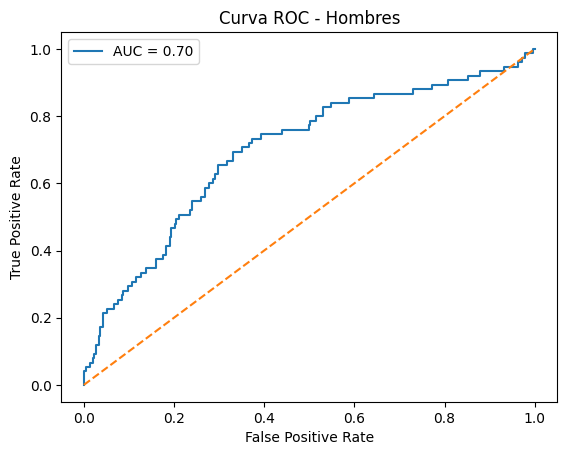

In [91]:
# Graficamos la curva ROC.
fpr_h, tpr_h, _ = roc_curve(y_test_h, y_prob_h)

plt.plot(fpr_h, tpr_h, label=f"AUC = {auc_h:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Hombres")
plt.legend()
plt.show()

##### Conclusión: 
Al segmentar el modelo de regresión logística según la variable sexo, se observó desbalance de clases en ambos subconjuntos, siendo más pronunciado en el grupo de mujeres. Por este motivo, se aplicó la técnica SMOTE en los conjuntos de entrenamiento.
Los resultados muestran una capacidad de discriminación similar en ambos modelos, con valores de ROC-AUC de 0,72 para mujeres y 0,70 para hombres. No obstante, el modelo para hombres presenta un mayor recall de la clase positiva (en mujeres 56% y en hombres 67%), lo que indica una mejor detección de individuos con riesgo coronario.
En conclusión, la separación por sexo permite identificar diferencias en el desempeño del modelo y aporta una interpretación más detallada del riesgo coronario.